In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import re # re stands for regular expression.......(useful for searching the text in a document)
#The statement import re imports Python's built-in re module, which provides full support for regular expressions (regex). Regular expressions are specialized text patterns used to match, search, extract, or modify string data efficiently.
import itertools

In [2]:
from nltk.corpus import stopwords #corpus means the body of the text and *nltk* stands for natural language toolkit
# imports the stopwords module from the Natural Language Toolkit (NLTK) library, which allows you to access and filter out common filler words (like "the", "is", and "at") during text preprocessing
from nltk.stem.porter import PorterStemmer 
from sklearn.feature_extraction.text import TfidfVectorizer # TfidfVectorizer converts the text into feature vectors(numbers)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import PassiveAggressiveClassifier
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shaur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shaur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shaur\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shaur\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
# printing the stopwords in english
stopwords =list(stopwords.words('english'))

In [6]:
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [7]:
lemmatizer = WordNetLemmatizer() #NLTK class that reduces words to their meaningful dictionary root (lemma) using the WordNet database.

## Data Preprocessing

In [8]:
## Loading dataset to a pandas DataFrame
fake= pd.read_csv("../Dataset/Fake.csv")
true= pd.read_csv("../Dataset/True.csv")


In [9]:
fake["label"] = 0
true["label"] = 1

dataset= pd.concat([fake, true], ignore_index=True)

In [10]:
dataset

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
...,...,...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",1


In [11]:
dataset.shape

(44898, 5)

In [12]:
fake.shape

(23481, 5)

In [13]:
true.shape

(21417, 5)

In [14]:
# Print the first 5 rows of the Dataframe

dataset.head(10)

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [15]:
## Counting the no. of missing values in the dataset

dataset.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [16]:
dataset.duplicated().sum()

np.int64(209)

In [17]:
dataset.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

In [18]:
dataset = dataset.drop(['subject','date'], axis=1)

In [19]:
dataset

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,0
...,...,...,...
44893,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,1
44894,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",1
44895,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,1
44896,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,1


In [20]:
# Separating the data & labels 
x= dataset.drop('label',axis=1)
y= dataset['label']

In [21]:
print(x)
print(y)

                                                   title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
44893  'Fully committed' NATO backs new U.S. approach...   
44894  LexisNexis withdrew two products from Chinese ...   
44895  Minsk cultural hub becomes haven from authorities   
44896  Vatican upbeat on possibility of Pope Francis ...   
44897  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text  
0      Donald Trump just couldn t wish all Americans ...  
1      House Intelligence Committee Chairman Devin Nu...  
2      On Friday, it was revealed that former Milwauk...  
3      On Christmas day, Donald Trump annou

In [22]:
dataset['text'][55]

"We re not sure why Fox News host Sean Hannity posed for this picture (see below) since he s obviously not happy with it but now, Donald Trump s cult member is upset with the New York Times for selecting the photo for the cover of its magazine. Along with the photo, the cover reads,  How Far Will Sean Hannity Go? So @nytimes takes 100 s and 100 s of pics. Obviously they picked the best one?  the Fox News host tweeted to his more than 3.1 million followers.So @nytimes takes 100 s and 100 s of pics. Obviously they picked the best one? https://t.co/6c0yV1lupe  Sean Hannity (@seanhannity) November 28, 2017Here s the photo that s freaking Hannity out.Internet users thought Hannity s reaction to the photo was pretty funny.Snowflake much Sean?  Paul Dickinson (@prdickinson) November 28, 2017We re wondering the same thing.Why would this dummy pose for a photo like that if he didn't want them to use it?     CaptainPajamas (@captainpajamas) November 28, 2017Makes you look young. And deranged. So

**LEMMATIZATION**

Lemmatization is the process of reducing words to their base or dictionary form, known as the "lemma." 
In natural language processing (NLP), lemmatization is an important technique used to normalize text data by removing 			  inflections, conjugations, and other variations of a word to bring them to their root form.

         example:the word "cats" can be lemmatized to "cat",
		 	    "running" to "run", 
		 	    "am" to "be"
		 	    "ate" to "eat"
Lemmatization is similar to stemming, but it produces more accurate results because it takes into account the context of the 			word in a sentence and uses more advanced linguistic analysis to identify the base form.
Lemmatization can improve the accuracy of text analysis and machine learning models that rely on text data.

In [23]:
for x in range(len(dataset)):
    corpus = []
    review = str(dataset['title'][x])
    review = re.sub(r'[^a-zA-Z\s]', '', review)
    review = review.lower()
    review = nltk.word_tokenize(review)

    for y in review:
        if y not in stopwords:
            corpus.append(lemmatizer.lemmatize(y))

    review = ' '.join(corpus)
    dataset.loc[x, 'title'] = review

#### Splitting the dataset to training and test data

In [24]:
x = dataset['title'].values
y = dataset['label'].values

In [25]:
x_train, x_test, y_train, y_test= train_test_split(x,y,
                                                   test_size=0.2,
                                                   stratify=y,
                                                   random_state=42)

In [26]:
x_train.shape

(35918,)

In [27]:
x_test.shape

(8980,)

**CONVERTING THE TEXTUAL DATA TO NUMERICAL DATA**

converting to textual data into numerical data/feature vector

1)**tf (term freequency)**:-which counts the number of time a perticular words is repearting in a documents.

2)**idf (inverse document freequency)**:-Measure the word is a rare word or common word in a document

In [28]:
#converting to textual data into numerical data/feature vector

vectorizer = TfidfVectorizer()
tfidf_X_train = vectorizer.fit_transform(x_train)
tfidf_X_test = vectorizer.transform(x_test)

In [29]:
print(tfidf_X_train,tfidf_X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 327188 stored elements and shape (35918, 20614)>
  Coords	Values
  (0, 16986)	0.5217208746413994
  (0, 16013)	0.16668679595020336
  (0, 20422)	0.46117991600657354
  (0, 8320)	0.39966264237938287
  (0, 12118)	0.28325774172401197
  (0, 7455)	0.3459310734062071
  (0, 119)	0.35735478530895604
  (1, 12437)	0.26862288837592435
  (1, 2793)	0.3863820263277067
  (1, 7933)	0.3134038847645737
  (1, 3676)	0.5442952721614978
  (1, 5850)	0.2701588457210973
  (1, 4777)	0.3418723422978535
  (1, 12852)	0.44069131479870327
  (2, 16013)	0.09958021033969265
  (2, 7933)	0.16120227975579624
  (2, 5850)	0.1389587811240753
  (2, 18761)	0.12614296410051287
  (2, 6930)	0.2852271581736559
  (2, 19513)	0.45646944933917594
  (2, 4760)	0.3855254190290748
  (2, 16321)	0.14764293982228574
  (2, 20327)	0.16480005609892615
  (2, 19802)	0.13757273759496313
  (2, 13253)	0.2999748787640936
  :	:
  (35915, 688)	0.2966991816995337
  (35915, 3395)	0.23321176113381

In [30]:
tfidf_X_train.shape

(35918, 20614)

### Training the model

In [31]:
model= LogisticRegression()

In [32]:
model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [33]:
model.fit(tfidf_X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [34]:
y_pred= model.predict(tfidf_X_test)

### Evaluation 

In [35]:
# calculating accuracy score on training data
x_train_pred= model.predict(tfidf_X_train)
accuracy= accuracy_score(x_train_pred, y_train)

In [36]:
accuracy

0.9623030235536499

In [37]:
# calculating accuracy score on testing data
y_pred= model.predict(tfidf_X_test)
accuracy= accuracy_score(y_pred, y_test)

In [38]:
accuracy

0.9462138084632516

**CLASSIFICATION MODEL:-PASSIVE AGGRESSIVE CLASSIFIER**

Passive: if correct classification, keep the model; Aggressive: if incorrect classification, update to adjust to this misclassified example.

Passive-Aggressive algorithms are generally used for large-scale learning. It is one of the few 'online-learning algorithmns. In online machine learning algorithms, the input data comes in sequential order and the machine learning model is updated step-by-step, as opposed to batch learning, where the entire training dataset is used at once. This is very useful in situations where there is a huge amount of data and it is computationally infeasible to train the entire dataset because of the sheer size of the data. We can simply say that an online-leaming algorithm will get a training example, update the classifier, and then throw away the example.

In [39]:
#model and model training

classifier = PassiveAggressiveClassifier()
classifier.fit(tfidf_X_train,y_train)

c:\Users\Shaur\OneDrive\Desktop\Fake_News_Detection\Project1\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


,"C C: float, default=1.0Aggressiveness parameter for the passive-aggressive algorithm, see [1].For PA-I it is the maximum step size. For PA-II it regularizes thestep size (the smaller `C` the more it regularizes).As a general rule-of-thumb, `C` should be small when the data is noisy.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`~sklearn.linear_model.PassiveAggressiveClassifier.partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically set asidea stratified fraction of training data as validation and terminatetraining when validation score is not improving by at least `tol` for`n_iter_no_change` consecutive epochs... versionadded:: 0.20",False
,"validation_fraction validation_fraction: float, default=0.1The proportion of training data to set aside as validation set forearly stopping. Must be between 0 and 1.Only used if early_stopping is True... versionadded:: 0.20",0.1
,"n_iter_no_change n_iter_no_change: int, default=5Number of iterations with no improvement to wait before early stopping... versionadded:: 0.20",5
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"loss loss: str, default=""hinge""The loss function to be used:hinge: equivalent to PA-I in the reference paper.squared_hinge: equivalent to PA-II in the reference paper.",'hinge'
,"n_jobs n_jobs: int or None, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None


In [40]:
# calculating accuracy score on training data
x_train_pred= classifier.predict(tfidf_X_train)
accuracy= accuracy_score(x_train_pred, y_train)

In [41]:
accuracy

0.9995545408987138

In [42]:
# calculating accuracy score on testing data
y_pred= classifier.predict(tfidf_X_test)
accuracy= accuracy_score(y_pred, y_test)

In [43]:
accuracy

0.9413140311804009

## Confusion_matrix

In [44]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Accuracy: 94.13%
Confusion matrix, without normalization


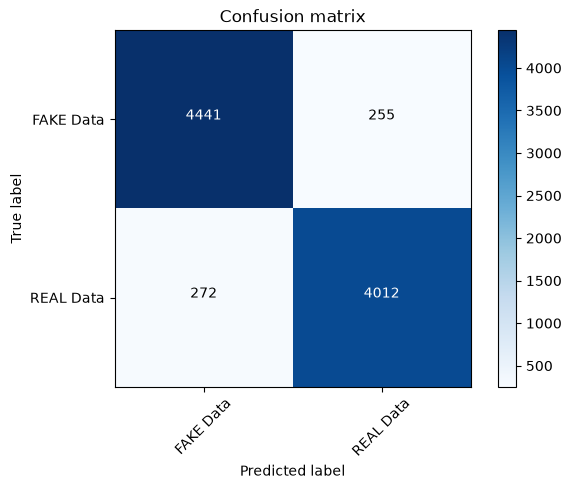

In [45]:

print(f'Accuracy: {round(accuracy*100,2)}%')
cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, classes=['FAKE Data', 'REAL Data'])

## Classification report

In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94      4696
           1       0.94      0.94      0.94      4284

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



## Saving & Loading model

In [47]:
#pickling the model into disk
import pickle
pickle.dump(model,open('./model.pkl', 'wb'))
pickle.dump(vectorizer,open('vector.pkl', 'wb'))

In [48]:
# load the model from disk
loaded_model = pickle.load(open('./model.pkl', 'rb'))
#vector_form = pickle.load(open('vector.pkl', 'rb'))

## Building a Predictive system

In [49]:
def fake_news_det(news):
    review = news
    review = re.sub(r'[^a-zA-Z\s]', '', review)
    review = review.lower()
    review = nltk.word_tokenize(review)
    corpus = []
    for y in review :
        if y not in stopwords :
            corpus.append(lemmatizer.lemmatize(y))     
    input_data = [' '.join(corpus)]
    vectorized_input_data = vectorizer.transform(input_data)
    prediction = loaded_model.predict(vectorized_input_data)
    if prediction[0] == 1:
        print("Prediction of the News :  Looking Real News📰 ")
    else:
        print("Prediction of the News : Looking Fake⚠ News📰 ")
      

In [50]:
x_test

<StringArray>
[                           'trump name mcgahn white house counsel transition official',
                       'senate judiciary committee seek comey memo possible trump tape',
         'south carolina governor nikki haley say weve never passed racist law country',
                        'china internet regulator denounces former chief investigation',
                                                 'minsk cultural hub becomes authority',
                    'trump going make measles great meet top antivaxxer discus vaccine',
                               'trump unveils company million u drug packaging project',
                                                       'year review top ten conspiracy',
                                        'urge trump expand obamacare ensure healthcare',
                               'clinton would stick garland nominee supreme court reid',
 ...
              'lying liar behind baby part video reject plea deal demand apology video',
 '

In [51]:
x_test[55]

'spectacular leftist medium melt realize america didnt buy lieselected trump anyhow video'

In [52]:
y_test[55]

np.int64(0)

In [53]:
news=str(input("Enter the News:"))
fake_news_det(news)

Prediction of the News : Looking Fake⚠ News📰 


**Manual Prediction**

In [54]:
print(tfidf_X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 80038 stored elements and shape (8980, 20614)>
  Coords	Values
  (0, 4049)	0.5153924224501557
  (0, 8886)	0.2838176730543977
  (0, 12077)	0.43430039094135586
  (0, 12711)	0.34928060595012983
  (0, 18646)	0.4838244523905465
  (0, 18761)	0.14975259684811648
  (0, 20149)	0.2944358454476564
  (1, 3546)	0.3149144830621256
  (1, 3589)	0.35093655489027736
  (1, 9977)	0.42031504428648814
  (1, 11441)	0.40408128664096954
  (1, 13857)	0.3465668507745566
  (1, 16248)	0.29795202321832126
  (1, 16316)	0.2545096114989535
  (1, 18026)	0.3888148549094125
  (1, 18761)	0.113533502514558
  (2, 2793)	0.2975517794636208
  (2, 4067)	0.26780742975274385
  (2, 7933)	0.24135150511224343
  (2, 8264)	0.3371580867638125
  (2, 10416)	0.2297489719924648
  (2, 12244)	0.27411002482003266
  (2, 12335)	0.3716732685700088
  (2, 13264)	0.3629993565089745
  (2, 14619)	0.2382830307986312
  :	:
  (8976, 48)	0.3692907400605139
  (8976, 987)	0.37892846470961383
  (

In [55]:
print(y_test)

[1 1 0 ... 1 1 0]


In [56]:
X_new=tfidf_X_test[777]
prediction = loaded_model.predict(X_new)

if (prediction[0] == 1):
	print("Prediction of the News :  Looking Real News📰 ")
else:
	print("Prediction of the News : Looking Fake⚠ News📰 ")

Prediction of the News : Looking Fake⚠ News📰 


In [57]:
print(y_test[777])

0


In [58]:
import joblib
import os

# Create model directory
os.makedirs('../model', exist_ok=True)

# Save model and vectorizer
joblib.dump(model, '../model/Logistic_Regression.pkl')
joblib.dump(vectorizer, '../model/tfidf_vectorizer.pkl')

print("✅ Model and Vectorizer saved successfully!")

✅ Model and Vectorizer saved successfully!
